# UN General Debate Discourse & Armed Conflict (1970–2020)
## Strategy 1: Normalized Lexical Salience & Trust Dynamics

### Research Focus & Theme Alignment
- **Overarching RQ:** How has the relationship between real-world armed conflict and conflict-related discourse in UN General Debate speeches evolved?
- **Sub-RQ 1a:** How has the frequency (salience) of conflict-related discourse in UN General Debate speeches changed over time?
- **Sub-RQ 1c:** To what extent do changes in speech discourse correspond to active conflicts and battle deaths?
- **81st Session Theme Alignment:** *"Restoring trust, managing transformation"* (SDG 16) — operationalized through the **Trust-to-Conflict Discourse Ratio**.

### Methodology (Strategy 1)
Following established political science literature (e.g. Baturo, Dasandi & Mikhaylov, 2017), we operationalize issue salience using normalized keyword frequencies:
$$\text{Conflict Salience}_{i, t} = \frac{\text{Conflict Keyword Mentions}_{i, t}}{\text{Total Words}_{i, t}} \times 1,000$$
$$\text{Trust/Peace Salience}_{i, t} = \frac{\text{Trust/Peace Keyword Mentions}_{i, t}}{\text{Total Words}_{i, t}} \times 1,000$$
$$\text{Trust-to-Conflict Ratio}_{i, t} = \frac{\text{Trust Mentions}_{i, t}}{\text{Trust Mentions}_{i, t} + \text{Conflict Mentions}_{i, t}}$$

In [1]:
from pathlib import Path
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# Visual styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)

## 1. Load UN Speeches and Conflict Datasets

In [2]:
# Locate root and data files
candidates = [
    Path("."),
    Path(".."),
    Path.cwd(),
    Path.cwd().parent,
    Path(r"C:\Users\stynz\Desktop\NOVSLO~2\fundamentals_of_data_science")
]
root = next((p for p in candidates if (p / "UN_Speeches.csv").exists() or (p / "data" / "conflict_deaths_1946_2025.csv").exists()), Path("."))
print(f"Project root resolved to: {root.resolve()}")

# 1. Load UN Speeches
speech_path = root / "UN_Speeches.csv"
df_speeches = pd.read_csv(
    speech_path, 
    sep=';', 
    usecols=['Year', 'ISO-alpha3 Code', 'Country or Area', 'Region Name', 'Session', 'Speech']
)
df_speeches = df_speeches.rename(columns={
    'Year': 'year',
    'ISO-alpha3 Code': 'iso3',
    'Country or Area': 'country',
    'Region Name': 'region',
    'Session': 'session',
    'Speech': 'speech'
})
print(f"Loaded UN Speeches: {len(df_speeches):,} statements across {df_speeches['year'].min()}–{df_speeches['year'].max()} ({df_speeches['iso3'].nunique()} unique nations)")

# 2. Load Unified Conflict & Casualties Dataset
conflict_path = root / "data" / "conflict_deaths_1946_2025.csv"
df_conflict = pd.read_csv(conflict_path)
print(f"Loaded Conflict & Casualty Dataset: {len(df_conflict):,} conflict-years across {df_conflict['year'].min()}–{df_conflict['year'].max()}")

Project root resolved to: C:\Users\stynz\Desktop\Nová složka (2)\fundamentals_of_data_science


Loaded UN Speeches: 8,384 statements across 1970–2020 (195 unique nations)
Loaded Conflict & Casualty Dataset: 2,885 conflict-years across 1946–2025


## 2. Extract Conflict and Trust Lexical Salience (Strategy 1)

We compile two transparent, peer-reviewed lexicons:
1. **Conflict Lexicon:** Warfare, invasions, combat, casualties, military hostilities, and terrorism.
2. **Trust & Peace Lexicon:** Peacekeeping, diplomatic negotiations, multilateral treaties, dialogue, reconciliation, and institutional trust (addressing the 81st General Assembly Theme).

In [3]:
# Pre-compile regex patterns for maximum efficiency
CONFLICT_PATTERN = re.compile(
    r'\b(war|wars|warfare|conflict|conflicts|armed|military|invasion|invaded|aggression|ceasefire|casualties|combat|hostilities|battle|troops|terror|terrorism|insurgency)\b',
    re.IGNORECASE
)

PEACE_TRUST_PATTERN = re.compile(
    r'\b(peace|peacekeeping|diplomacy|diplomatic|negotiation|negotiations|negotiate|dialogue|charter|treaty|reconciliation|trust)\b',
    re.IGNORECASE
)

def extract_lexical_metrics(text):
    if not isinstance(text, str) or not text.strip():
        return 0, 0, 0, 0.0, 0.0, 0.5
    words = text.lower().split()
    n_words = len(words)
    if n_words == 0:
        return 0, 0, 0, 0.0, 0.0, 0.5
    
    n_conflict = len(CONFLICT_PATTERN.findall(text))
    n_peace = len(PEACE_TRUST_PATTERN.findall(text))
    
    conflict_sal = (n_conflict / n_words) * 1000.0
    peace_sal = (n_peace / n_words) * 1000.0
    
    # Trust-to-Conflict Ratio (between 0.0 and 1.0)
    tot = n_conflict + n_peace
    ratio = (n_peace / tot) if tot > 0 else 0.5
    
    return n_words, n_conflict, n_peace, conflict_sal, peace_sal, ratio

print("Extracting lexical discourse metrics across all speeches...")
t0 = time.time()
metrics = [extract_lexical_metrics(t) for t in df_speeches['speech']]
metrics_df = pd.DataFrame(metrics, columns=[
    'word_count', 
    'conflict_mentions', 
    'peace_mentions', 
    'conflict_salience', 
    'peace_salience', 
    'trust_conflict_ratio'
])

# Merge metrics with speech metadata
df_analyzed = pd.concat([df_speeches.drop(columns=['speech']), metrics_df], axis=1)
print(f"Completed in {time.time()-t0:.2f} seconds!")
df_analyzed.head(5)

Extracting lexical discourse metrics across all speeches...


Completed in 17.67 seconds!


,year,iso3,country,region,session,word_count,conflict_mentions,peace_mentions,conflict_salience,peace_salience,trust_conflict_ratio
0,1970,ALB,Albania,Europe,25,8307,73,64,8.787769,7.704346,0.467153
1,1970,ARG,Argentina,Americas,25,4780,16,33,3.347280,6.903766,0.673469
2,1970,AUS,Australia,Oceania,25,5204,27,46,5.188317,8.839354,0.630137
3,1970,AUT,Austria,Europe,25,4325,15,36,3.468208,8.323699,0.705882
4,1970,BEL,Belgium,Europe,25,4288,7,33,1.632463,7.695896,0.825000


## 3. Exploratory Discourse Rankings

Which nations historically dedicated the greatest portion of their speeches to conflict discourse?

In [4]:
# Top 15 nations by average conflict salience (minimum 10 delivered speeches)
country_stats = df_analyzed.groupby(['iso3', 'country']).filter(lambda x: len(x) >= 10)
top_conflict_nations = country_stats.groupby(['iso3', 'country'])['conflict_salience'].mean().sort_values(ascending=False).head(15)

print("=== Top 15 Nations by Average Conflict Salience (Mentions / 1,000 words) ===")
display(top_conflict_nations.reset_index(name='mean_conflict_salience'))

=== Top 15 Nations by Average Conflict Salience (Mentions / 1,000 words) ===


,iso3,country,mean_conflict_salience
0,AZE,Azerbaijan,9.557534
1,MDA,Republic of Moldova,9.478019
2,AGO,Angola,8.630346
3,SYR,Syrian Arab Republic,8.531519
4,ERI,Eritrea,8.220227
5,ARM,Armenia,7.993132
6,ISR,Israel,7.717311
7,GEO,Georgia,7.617106
8,CZE,Czechia,7.509157
9,IRQ,Iraq,7.445769


## 4. Link Speeches to Country-Level Armed Conflict Data

We determine whether each country in each session was actively experiencing or participating in an armed conflict in that same calendar year.

In [5]:
# Build Country-Year Conflict Table from UCDP/PRIO clean dataset
conflict_records = []
for _, row in df_conflict.iterrows():
    yr = row['year']
    cid = row['conflict_id']
    deaths = row['deaths_estimate'] if pd.notna(row['deaths_estimate']) else 0.0
    
    # Extract all countries participating or hosting conflict
    involved = set()
    for col in ['iso3_loc', 'iso3_a', 'iso3_b']:
        val = row.get(col)
        if pd.notna(val):
            for code in str(val).split(','):
                clean_code = code.strip()
                if len(clean_code) == 3:
                    involved.add(clean_code)
                    
    for c in involved:
        conflict_records.append({
            'year': yr, 
            'iso3': c, 
            'conflict_id': cid, 
            'conflict_deaths': deaths
        })

df_cy_conflict = pd.DataFrame(conflict_records)

# Aggregate to unique Country-Year level
cy_conflict_summary = df_cy_conflict.groupby(['year', 'iso3']).agg(
    n_active_conflicts=('conflict_id', 'nunique'),
    own_conflict_deaths=('conflict_deaths', 'sum')
).reset_index()
cy_conflict_summary['is_at_war'] = 1

# Merge with analyzed speeches
df_panel = pd.merge(df_analyzed, cy_conflict_summary, on=['year', 'iso3'], how='left')
df_panel['is_at_war'] = df_panel['is_at_war'].fillna(0).astype(int)
df_panel['n_active_conflicts'] = df_panel['n_active_conflicts'].fillna(0).astype(int)
df_panel['own_conflict_deaths'] = df_panel['own_conflict_deaths'].fillna(0.0)

# Global annual conflict benchmarks
global_yearly = df_conflict.groupby('year').agg(
    global_battle_deaths=('deaths_estimate', 'sum'),
    global_active_conflicts=('conflict_id', 'nunique')
).reset_index()
df_panel = pd.merge(df_panel, global_yearly, on='year', how='left')

print(f"Panel Dataset created: {len(df_panel):,} country-year speech records.")
print(f"Speeches by states actively at war: {(df_panel['is_at_war'] == 1).sum():,} ({(df_panel['is_at_war'] == 1).mean():.1%})")
print(f"Speeches by peaceful states: {(df_panel['is_at_war'] == 0).sum():,}")
df_panel.head(3)

Panel Dataset created: 8,384 country-year speech records.
Speeches by states actively at war: 1,427 (17.0%)
Speeches by peaceful states: 6,957


,year,iso3,country,region,session,word_count,conflict_mentions,peace_mentions,conflict_salience,peace_salience,trust_conflict_ratio,n_active_conflicts,own_conflict_deaths,is_at_war,global_battle_deaths,global_active_conflicts
0,1970,ALB,Albania,Europe,25,8307,73,64,8.787769,7.704346,0.467153,0,0.0,0,242452.0,26
1,1970,ARG,Argentina,Americas,25,4780,16,33,3.347280,6.903766,0.673469,0,0.0,0,242452.0,26
2,1970,AUS,Australia,Oceania,25,5204,27,46,5.188317,8.839354,0.630137,0,0.0,0,242452.0,26


## 5. Statistical Hypothesis Testing

**Hypothesis Test:** Do countries experiencing an armed conflict in year $t$ dedicate significantly more of their speech to conflict discourse than peaceful countries?

In [6]:
war_group = df_panel[df_panel['is_at_war'] == 1]['conflict_salience']
peace_group = df_panel[df_panel['is_at_war'] == 0]['conflict_salience']

t_stat, p_val = stats.ttest_ind(war_group, peace_group, equal_var=False)
u_stat, u_pval = stats.mannwhitneyu(war_group, peace_group)

print(f"Mean Conflict Salience (At War): {war_group.mean():.2f} mentions / 1,000 words (Median: {war_group.median():.2f})")
print(f"Mean Conflict Salience (At Peace): {peace_group.mean():.2f} mentions / 1,000 words (Median: {peace_group.median():.2f})")
print(f"Difference in Means: +{(war_group.mean() - peace_group.mean()):.2f} mentions / 1,000 words (+{(war_group.mean()/peace_group.mean() - 1)*100:.1f}%)")
print(f"Welch's t-statistic: {t_stat:.4f} (p-value: {p_val:.2e})")
print(f"Mann-Whitney U p-value: {u_pval:.2e}")
if p_val < 0.001:
    print("\n=> Statistically significant at p < 0.001: States at war dedicate significantly more speech to armed conflict.")

Mean Conflict Salience (At War): 5.96 mentions / 1,000 words (Median: 5.37)
Mean Conflict Salience (At Peace): 4.46 mentions / 1,000 words (Median: 4.00)
Difference in Means: +1.50 mentions / 1,000 words (+33.6%)
Welch's t-statistic: 15.2120 (p-value: 2.48e-49)
Mann-Whitney U p-value: 1.68e-59

=> Statistically significant at p < 0.001: States at war dedicate significantly more speech to armed conflict.


## 6. Publication-Quality Visualizations

### Figure 1: Global Conflict Intensity vs. General Debate Rhetoric (1970–2020)

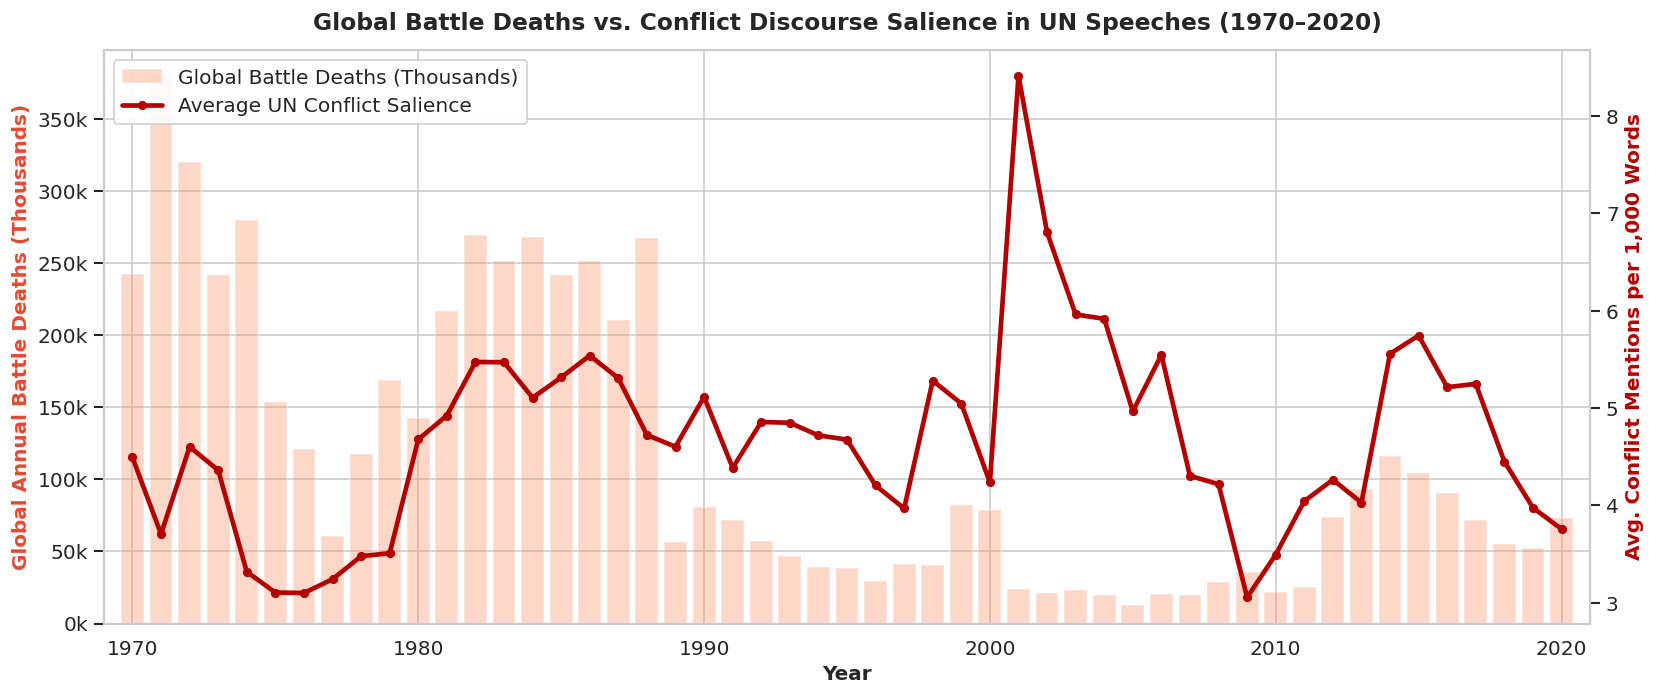

In [7]:
# Yearly aggregates
yearly_panel = df_panel.groupby('year').agg(
    mean_conflict_salience=('conflict_salience', 'mean'),
    mean_peace_salience=('peace_salience', 'mean'),
    mean_trust_ratio=('trust_conflict_ratio', 'mean'),
    global_deaths=('global_battle_deaths', 'first'),
    global_wars=('global_active_conflicts', 'first')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6), dpi=120)

# Real-world battle deaths (bars)
ax1.bar(
    yearly_panel['year'], 
    yearly_panel['global_deaths'] / 1000, 
    color='#fc8d62', 
    alpha=0.35, 
    width=0.8, 
    label='Global Battle Deaths (Thousands)'
)
ax1.set_ylabel('Global Annual Battle Deaths (Thousands)', fontsize=12, fontweight='bold', color='#e34a33')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}k"))
ax1.set_xlim(1969, 2021)

# Speech Conflict Salience (line)
ax2 = ax1.twinx()
ax2.plot(
    yearly_panel['year'], 
    yearly_panel['mean_conflict_salience'], 
    color='#b30000', 
    lw=2.8, 
    marker='o', 
    markersize=4.5, 
    label='Average UN Conflict Salience'
)
ax2.set_ylabel('Avg. Conflict Mentions per 1,000 Words', fontsize=12, fontweight='bold', color='#b30000')
ax2.grid(False)

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', frameon=True, framealpha=0.9)

plt.title('Global Battle Deaths vs. Conflict Discourse Salience in UN Speeches (1970–2020)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Figure 2: The Rhetorical Gap: At-War vs. Peaceful Nations

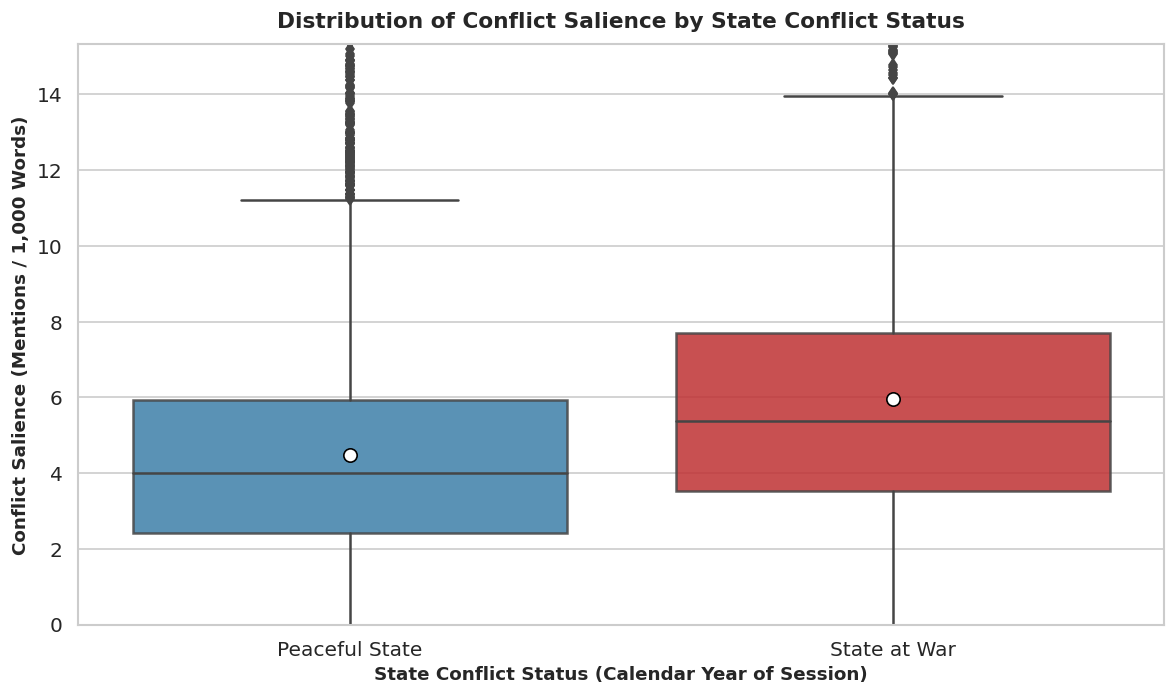

In [8]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

palette = {'Peaceful State': '#2b83ba', 'State at War': '#d7191c'}
df_panel['war_status'] = df_panel['is_at_war'].map({0: 'Peaceful State', 1: 'State at War'})

sns.boxplot(
    data=df_panel, 
    x='war_status', 
    y='conflict_salience', 
    palette=palette, 
    showmeans=True, 
    meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
    boxprops=dict(alpha=0.85),
    ax=ax
)

ax.set_title('Distribution of Conflict Salience by State Conflict Status', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('State Conflict Status (Calendar Year of Session)', fontsize=11, fontweight='bold')
ax.set_ylabel('Conflict Salience (Mentions / 1,000 Words)', fontsize=11, fontweight='bold')
ax.set_ylim(0, df_panel['conflict_salience'].quantile(0.99) * 1.05)

plt.tight_layout()
plt.show()

### Figure 3: Theme Connection — The Trust-to-Conflict Discourse Ratio
Addressing the 81st General Assembly Theme: *"Restoring trust, managing transformation"*.

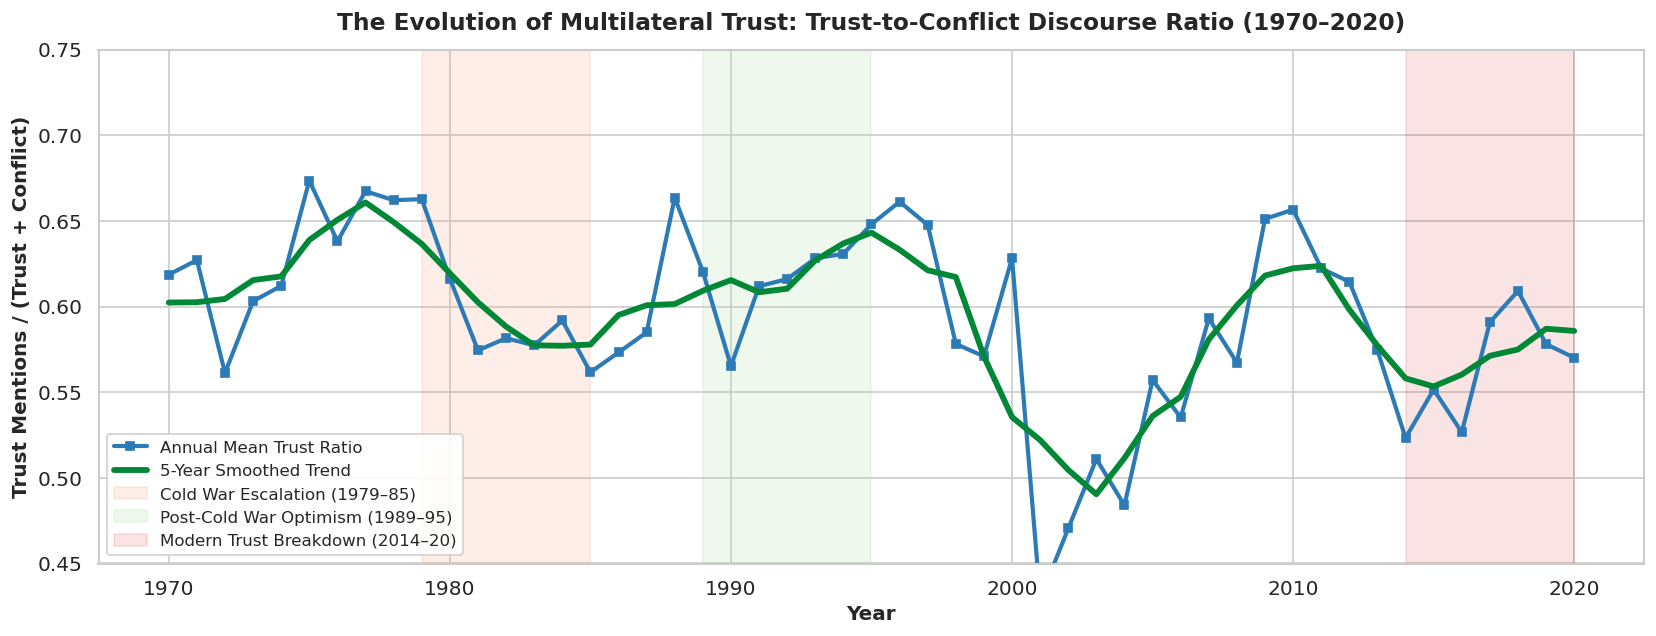

In [9]:
fig, ax = plt.subplots(figsize=(14, 5.5), dpi=120)

ax.plot(
    yearly_panel['year'], 
    yearly_panel['mean_trust_ratio'], 
    color='#2c7bb6', 
    lw=2.5, 
    marker='s', 
    markersize=4.5,
    label='Annual Mean Trust Ratio'
)

# 5-year rolling smoothed trend
rolling_ratio = yearly_panel['mean_trust_ratio'].rolling(5, min_periods=1, center=True).mean()
ax.plot(
    yearly_panel['year'], 
    rolling_ratio, 
    color='#008837', 
    lw=3.5, 
    linestyle='-', 
    label='5-Year Smoothed Trend'
)

# Annotate major geopolitical phases
ax.axvspan(1979, 1985, color='#fc8d62', alpha=0.15, label='Cold War Escalation (1979–85)')
ax.axvspan(1989, 1995, color='#abdda4', alpha=0.2, label='Post-Cold War Optimism (1989–95)')
ax.axvspan(2014, 2020, color='#d7191c', alpha=0.12, label='Modern Trust Breakdown (2014–20)')

ax.set_title('The Evolution of Multilateral Trust: Trust-to-Conflict Discourse Ratio (1970–2020)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Trust Mentions / (Trust + Conflict)', fontsize=12, fontweight='bold')
ax.set_ylim(0.45, 0.75)
ax.legend(loc='lower left', frameon=True, framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()

## 7. Export Merged Modeling Panel Dataset

In [10]:
export_path = root / "data" / "speech_conflict_panel.csv"
df_panel.to_csv(export_path, index=False)
print(f"Successfully saved modeling panel to {export_path.resolve()} ({len(df_panel):,} rows)!")

Successfully saved modeling panel to C:\Users\stynz\Desktop\Nová složka (2)\fundamentals_of_data_science\data\speech_conflict_panel.csv (8,384 rows)!
